<a href="https://colab.research.google.com/github/nikolas-joyce/Event_Time/blob/main/Event_Time_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Install yfinance once per session
!pip install yfinance --quiet

# Import libraries
import yfinance as yf
import pandas as pd

# Define the ticker symbols and date range
ticker_symbols = ['SPY', 'QQQ', 'DIA', 'GOOG', 'AAPL']  # SPY is SPDR S&P 500 ETF Trust, QQQ is Invesco QQQ Trust, DIA is SPDR Dow Jones Industrial Average ETF Trust, GOOG is Alphabet Inc., AAPL is Apple Inc.
start_date = '2010-01-01'
end_date = '2026-11-25'

# Download historical data for all tickers with adjusted close prices
data = yf.download(ticker_symbols, start=start_date, end=end_date, progress=True, auto_adjust=True, group_by='ticker', threads=True)

# Extract Close price for each ticker into a single DataFrame
close_prices = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in ticker_symbols})

# Display the first few rows of Close price data
(close_prices.head())


[*********************100%***********************]  5 of 5 completed


,SPY,QQQ,DIA,GOOG,AAPL
Date,,,,,
2010-01-04,85.279182,40.393559,75.132187,15.504140,6.418384
2010-01-05,85.504951,40.393559,75.011253,15.435865,6.429481
2010-01-06,85.565163,40.149925,75.061050,15.046746,6.327210
2010-01-07,85.926346,40.176010,75.331299,14.696465,6.315512
2010-01-08,86.212303,40.506687,75.452133,14.892385,6.357502


<Axes: xlabel='Date'>

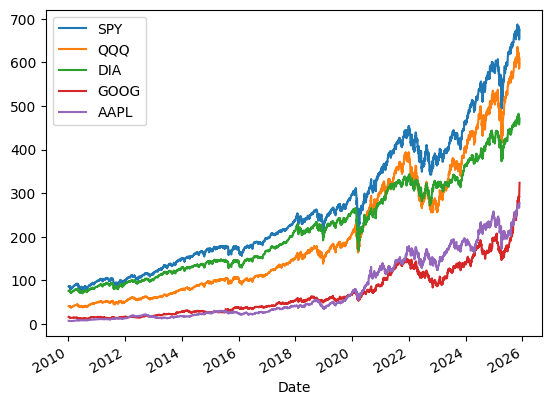

In [7]:
close_prices.plot()

In [8]:
import numpy as np

# Parameters
k = 0.5  # breakout multiplier constant
window = 20  # lookback window for volatility calculation

# Assuming 'close_prices' is your DataFrame with Close prices for multiple tickers

def volatility_breakout_strategy(df_close, k=0.5, window=20):
    """
    Volatility Breakout Strategy:
    Buy if today's close breaks above yesterday's close + k * yesterday's volatility range
    Sell signal or no position otherwise

    Args:
        df_close: DataFrame with Close prices indexed by date, columns = tickers
        k: multiplier for volatility range
        window: window size for volatility calc

    Returns:
        signals: DataFrame of boolean buy signals for each ticker and date
    """
    # Calculate daily returns volatility as rolling std of pct change
    vol = df_close.pct_change().rolling(window=window).std()

    # Calculate breakout threshold = yesterday's close + k * yesterday's volatility * yesterday's close
    shifted_close = df_close.shift(1)
    breakout_threshold = shifted_close * (1 + k * vol.shift(1))

    # Define buy signals when today's close > breakout threshold
    signals = df_close > breakout_threshold

    return signals

# Example usage with previously downloaded close_prices DataFrame
buy_signals = volatility_breakout_strategy(close_prices, k=k, window=window)

(buy_signals.tail())


,SPY,QQQ,DIA,GOOG,AAPL
Date,,,,,
2025-11-19,False,False,False,True,False
2025-11-20,False,False,False,False,False
2025-11-21,True,True,True,True,True
2025-11-24,True,True,True,True,True
2025-11-25,True,False,True,True,False


/tmp/ipython-input-2054217763.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)
/tmp/ipython-input-2054217763.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)
/tmp/ipython-input-2054217763.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, s

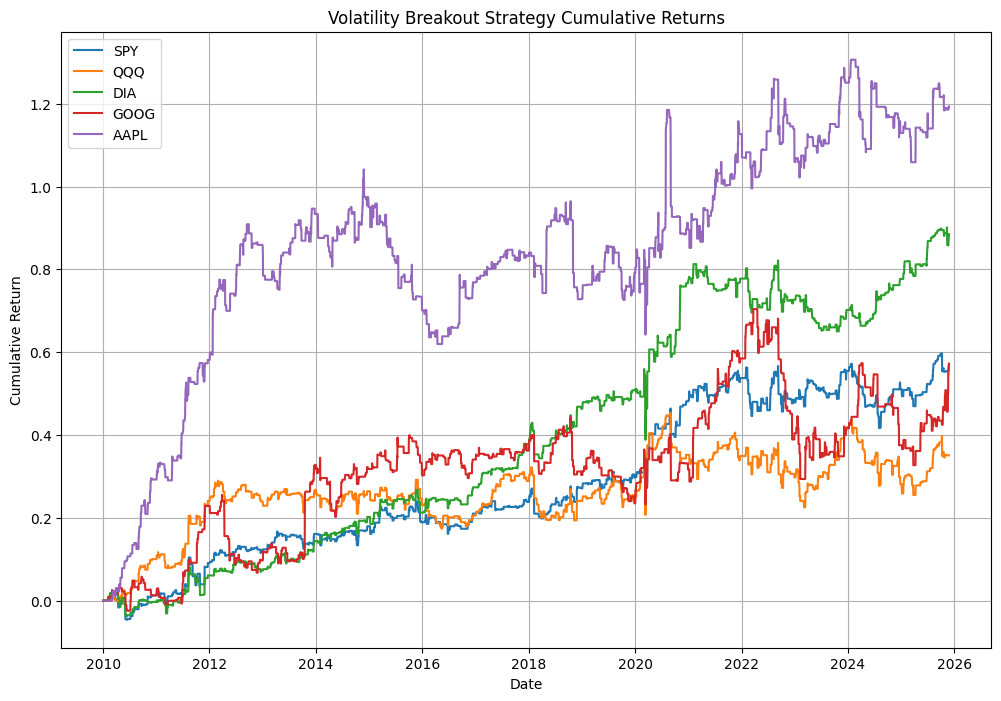

In [12]:
# Backtest volatility breakout strategy performance

initial_capital = 100000  # Starting portfolio value in USD
positions = pd.DataFrame(index=close_prices.index).fillna(0)  # To hold position sizes (units)
portfolio = pd.DataFrame(index=close_prices.index)  # To track portfolio value over time

# Generate buy signals using the volatility breakout function from step 3
buy_signals = volatility_breakout_strategy(close_prices, k=1.1, window=20)

# Assume we buy 1 unit of the asset when signal is True and hold until next signal
for ticker in buy_signals.columns:
    positions[ticker] = buy_signals[ticker].shift(1).fillna(False).astype(int)

# Calculate daily portfolio value = sum of position units * Close prices
portfolio['holdings'] = (positions * close_prices).sum(axis=1)

# Assume all capital is initially cash
portfolio['cash'] = initial_capital - (positions.diff().fillna(0) * close_prices).sum(axis=1).cumsum()

# Total portfolio value = holdings + cash
portfolio['total'] = portfolio['holdings'] + portfolio['cash']

# Calculate returns
portfolio['returns'] = portfolio['total'].pct_change()

import matplotlib.pyplot as plt

# Calculate daily strategy returns based on the portfolio total value change
portfolio['strategy_returns'] = portfolio['total'].pct_change().fillna(0)

# Calculate cumulative returns for each ticker based on buy signals and close prices
cumulative_returns = pd.DataFrame(index=close_prices.index)

for ticker in close_prices.columns:
    # Calculate daily returns when holding position (shift signals for execution delay)
    daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
    strategy_daily_returns = daily_returns * buy_signals[ticker].shift(1).fillna(False).astype(int)

    # Calculate cumulative returns over time
    cumulative_returns[ticker] = (1 + strategy_daily_returns).cumprod() - 1

# Plot cumulative returns for all tickers
plt.figure(figsize=(12, 8))
for ticker in cumulative_returns.columns:
    plt.plot(cumulative_returns[ticker], label=ticker)

plt.title('Volatility Breakout Strategy Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()



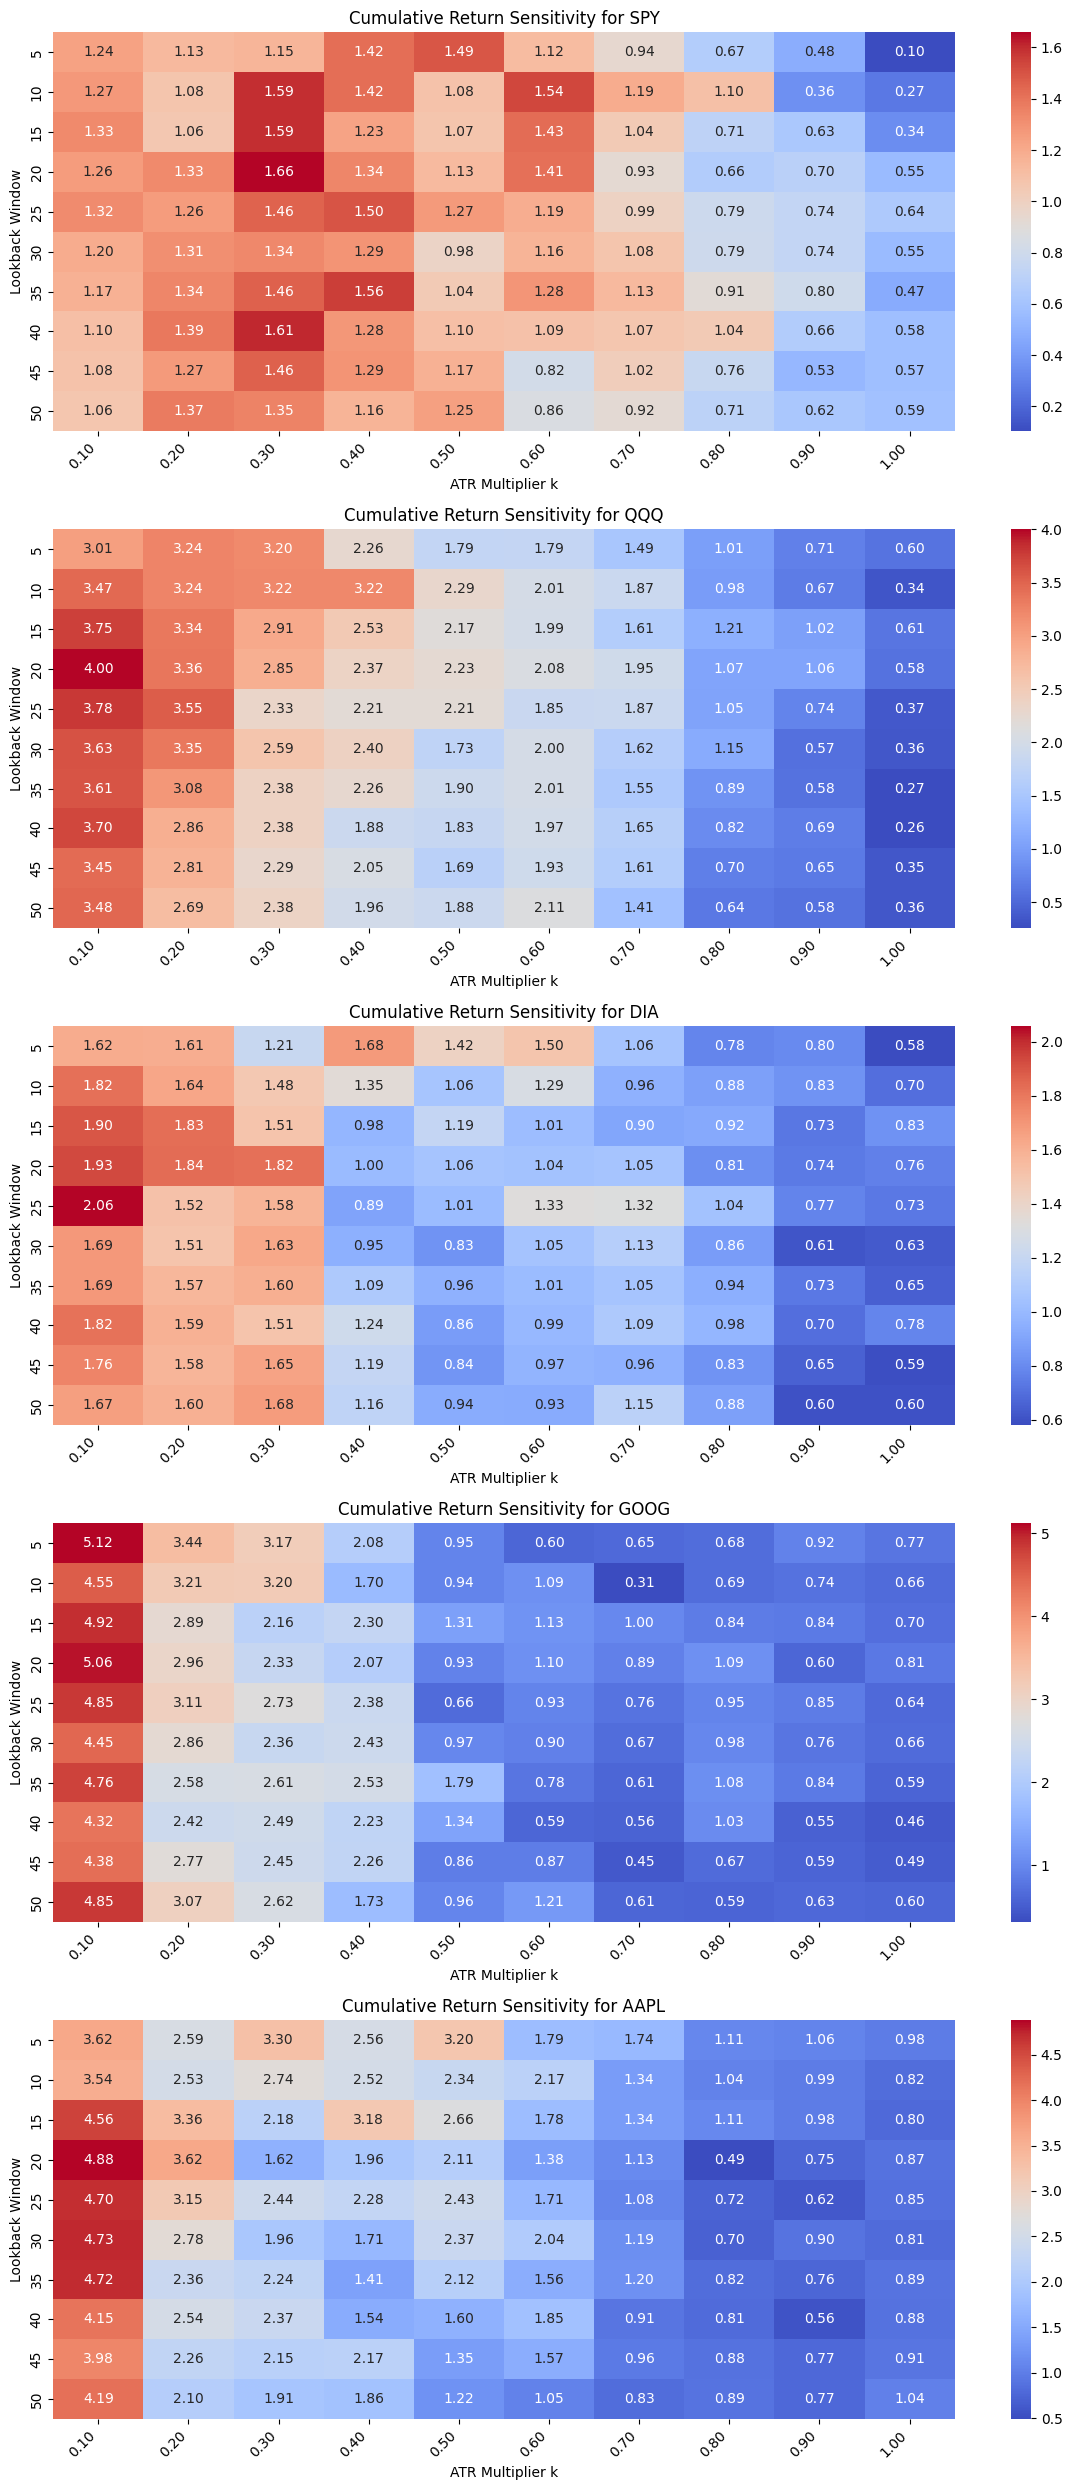

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress pandas FutureWarning for downcasting
pd.set_option('future.no_silent_downcasting', True)

# Assume 'close_prices' DataFrame and 'volatility_breakout_strategy' function are defined

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50 days
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 5 * len(tickers)))

if len(tickers) == 1:
    axes = [axes]  # ensure axes is iterable

for ax, ticker in zip(axes, tickers):
    pnl_matrix = pd.DataFrame(index=lookback_windows, columns=k_factors)

    for window in lookback_windows:
        for k in k_factors:
            # Generate breakout signals for the ticker with parameters
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)

            # Calculate daily returns shifted for execution delay
            daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
            strategy_returns = daily_returns * signals[ticker].shift(1).fillna(False).astype(int)

            # Calculate cumulative return
            cumulative_return = (1 + strategy_returns).prod() - 1
            pnl_matrix.at[window, k] = cumulative_return

    pnl_matrix = pnl_matrix.astype(float)

    # Plot heatmap with annotated cumulative returns
    sns.heatmap(pnl_matrix, ax=ax, cmap='coolwarm', annot=True, fmt=".2f")

    ax.set_title(f'Cumulative Return Sensitivity for {ticker}')
    ax.set_xlabel('ATR Multiplier k')
    ax.set_ylabel('Lookback Window')

    # Rotate x-axis labels 45 degrees, format numbers to two decimals, align right
    labels = [f"{x:.2f}" for x in pnl_matrix.columns]
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()


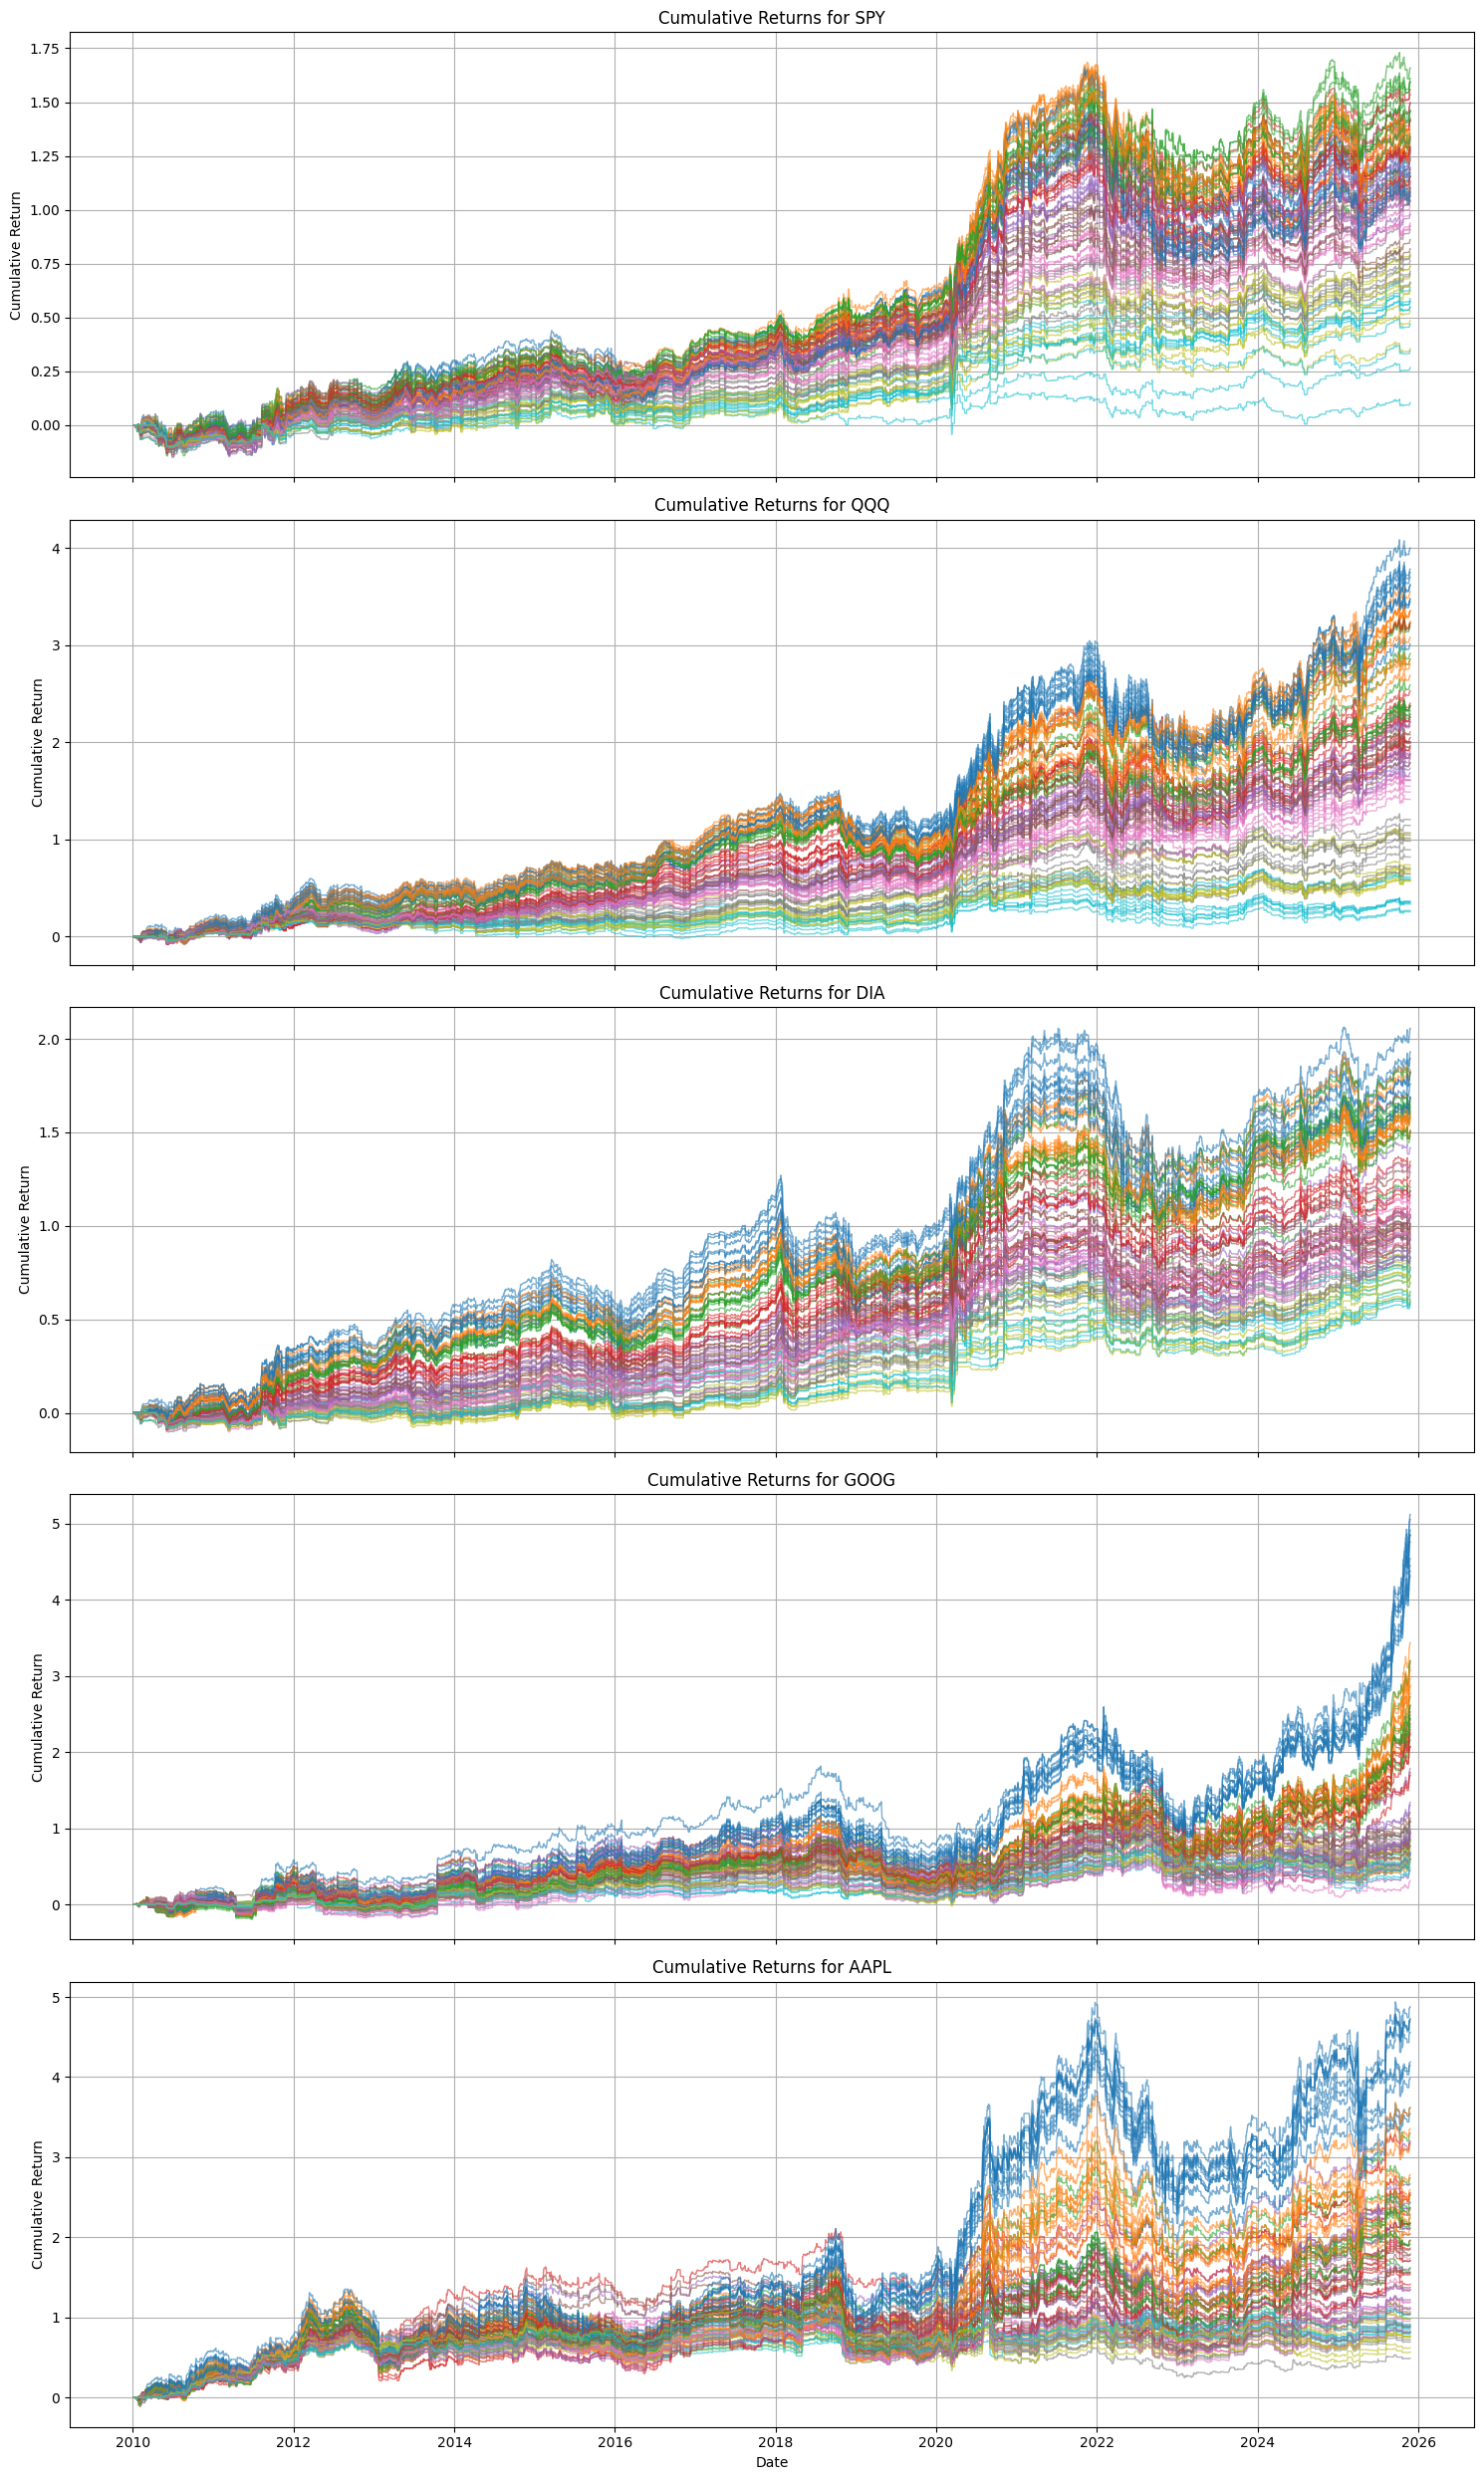

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # e.g. 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # e.g. 0.1 to 1.0

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(15, 5 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    for window in lookback_windows:
        for k in k_factors:
            # Generate signals for parameters
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)

            daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
            strategy_returns = daily_returns * signals[ticker].shift(1).fillna(False).astype(int)

            cumulative_returns = (1 + strategy_returns).cumprod() - 1

            # Plot without legend labels or label='_nolegend_'
            ax.plot(cumulative_returns.index, cumulative_returns, alpha=0.6, linewidth=1, label='_nolegend_')

    ax.set_title(f'Cumulative Returns for {ticker}')
    ax.set_ylabel('Cumulative Return')
    ax.grid(True)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


/tmp/ipython-input-3602822251.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  composite_returns.fillna(method='ffill', inplace=True)
/tmp/ipython-input-3602822251.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  composite_returns.fillna(method='ffill', inplace=True)
/tmp/ipython-input-3602822251.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  composite_returns.fillna(method='ffill', inplace=True)
/tmp/ipython-input-3602822251.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  composite_returns.fillna(method='ffill', inplace=True)
/tmp/ipython-input-3602822251.py:61: FutureWarning: Series.fillna with 'method' is deprecate

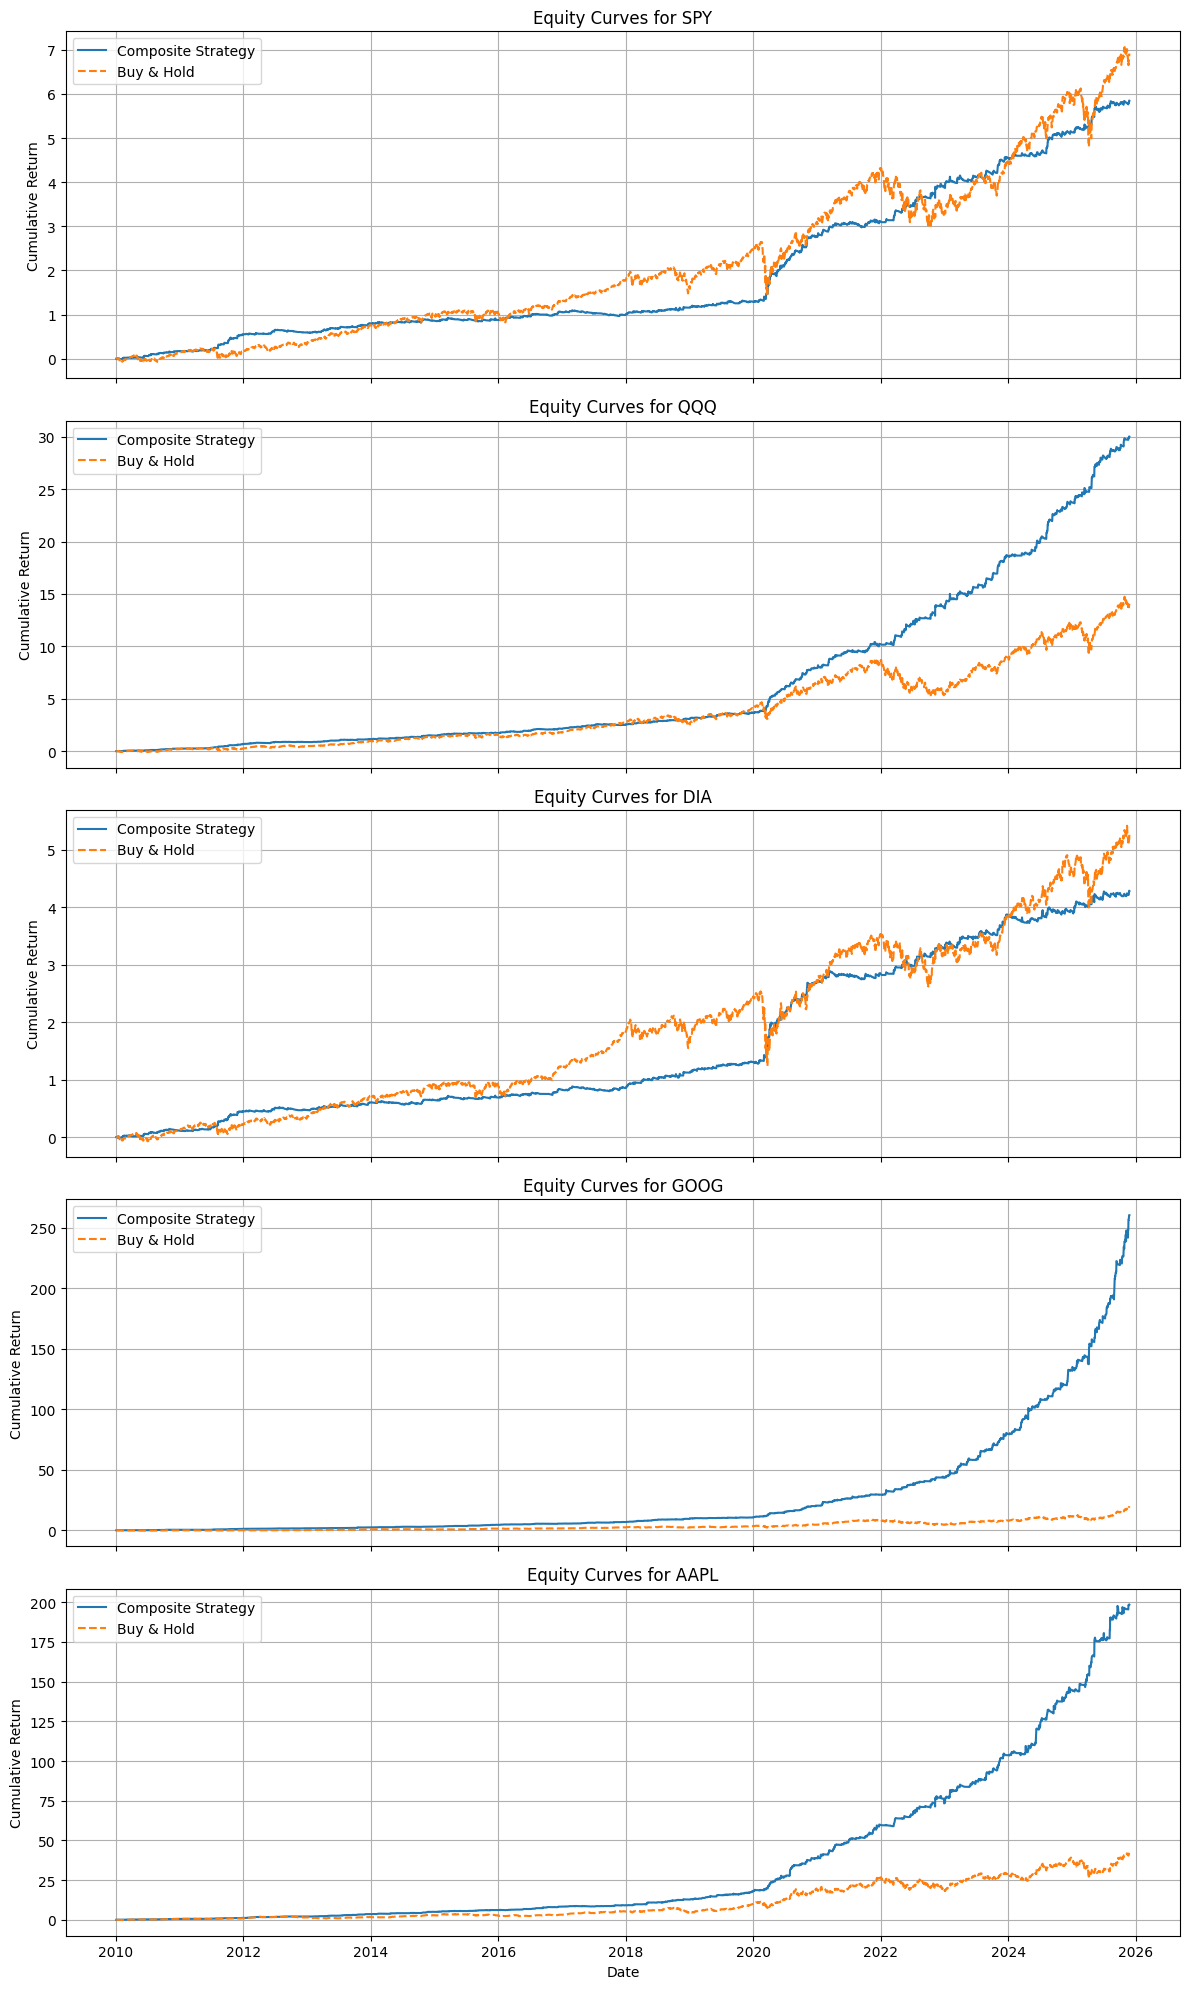

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress pandas FutureWarning for downcasting issues
pd.set_option('future.no_silent_downcasting', True)

tickers = close_prices.columns.tolist()
lookback_windows = range(5, 51, 5)  # Lookback periods: 5, 10, ..., 50
k_factors = np.arange(0.1, 1.1, 0.1)  # ATR multipliers: 0.1 to 1.0

rebalance_period = 5  # rebalance every 20 trading days

transaction_cost_per_trade = 0.0041  # e.g., 0.1% per round trip trade

composite_equity_curves = {}

for ticker in tickers:
    all_strategy_returns = pd.DataFrame(index=close_prices.index)

    for window in lookback_windows:
        for k in k_factors:
            signals = volatility_breakout_strategy(close_prices[[ticker]], k=k, window=window)
            daily_returns = close_prices[ticker].pct_change().shift(-1).fillna(0)
            strategy_returns = daily_returns * signals[ticker].shift(1).fillna(False).astype(int)
            col_name = f"w{window}_k{k:.2f}"
            all_strategy_returns[col_name] = strategy_returns

    composite_returns = pd.Series(index=close_prices.index)
    previous_weights = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns = all_strategy_returns.iloc[start:end]

        performance = (1 + window_returns).prod() - 1
        positive_perf = performance.clip(lower=0)
        total_perf = positive_perf.sum()

        if total_perf == 0:
            weights = positive_perf * 0
        else:
            weights = positive_perf / total_perf

        # Calculate turnover as sum of absolute weight changes from previous period
        turnover = (weights - previous_weights).abs().sum()
        previous_weights = weights

        # Transaction cost penalty
        cost = turnover * transaction_cost_per_trade

        weighted_returns = (window_returns * weights).sum(axis=1)

        # Subtract transaction cost uniformly over period
        cost_per_day = cost / (end - start)
        weighted_returns -= cost_per_day

        composite_returns.iloc[start:end] = weighted_returns.values

    composite_returns.fillna(method='ffill', inplace=True)
    composite_returns.fillna(0, inplace=True)

    composite_equity_curves[ticker] = (1 + composite_returns).cumprod() - 1


#import matplotlib.pyplot as plt

# composite_equity_curves is a dict of strategy equity curves by ticker
tickers = list(composite_equity_curves.keys())

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(12, 4 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    equity_curve = composite_equity_curves[ticker]

    # Compute buy-and-hold cumulative returns for ticker
    bh_prices = close_prices[ticker]
    bh_returns = bh_prices.pct_change().fillna(0)
    bh_cum_return = (1 + bh_returns).cumprod() - 1

    # Plot composite strategy equity curve
    ax.plot(equity_curve.index, equity_curve, label='Composite Strategy')

    # Overlay buy-and-hold equity curve
    ax.plot(bh_cum_return.index, bh_cum_return, label='Buy & Hold', linestyle='--')

    ax.set_title(f'Equity Curves for {ticker}')
    ax.set_ylabel('Cumulative Return')
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


/tmp/ipython-input-3798583896.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

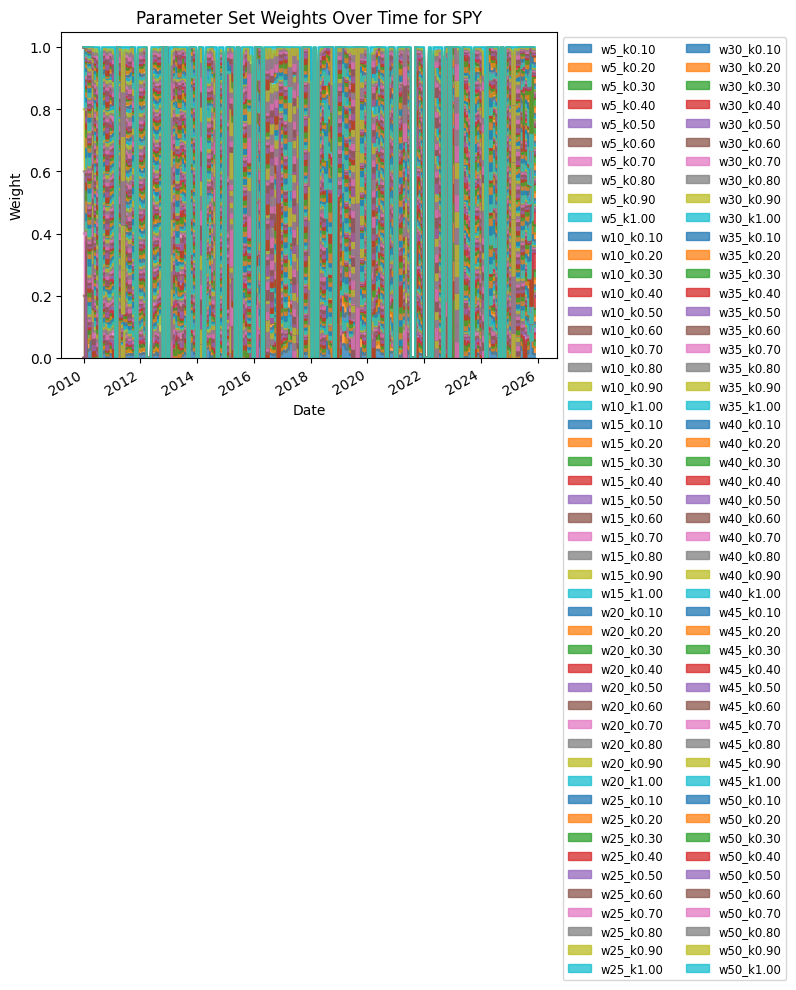

/tmp/ipython-input-3798583896.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

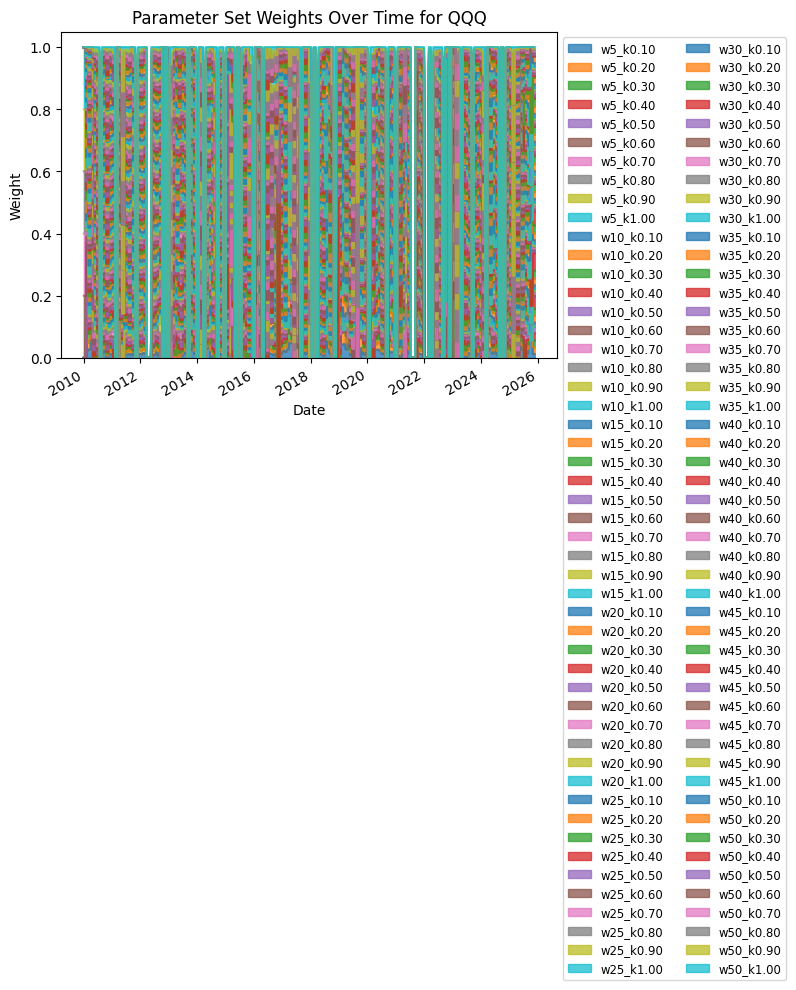

/tmp/ipython-input-3798583896.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

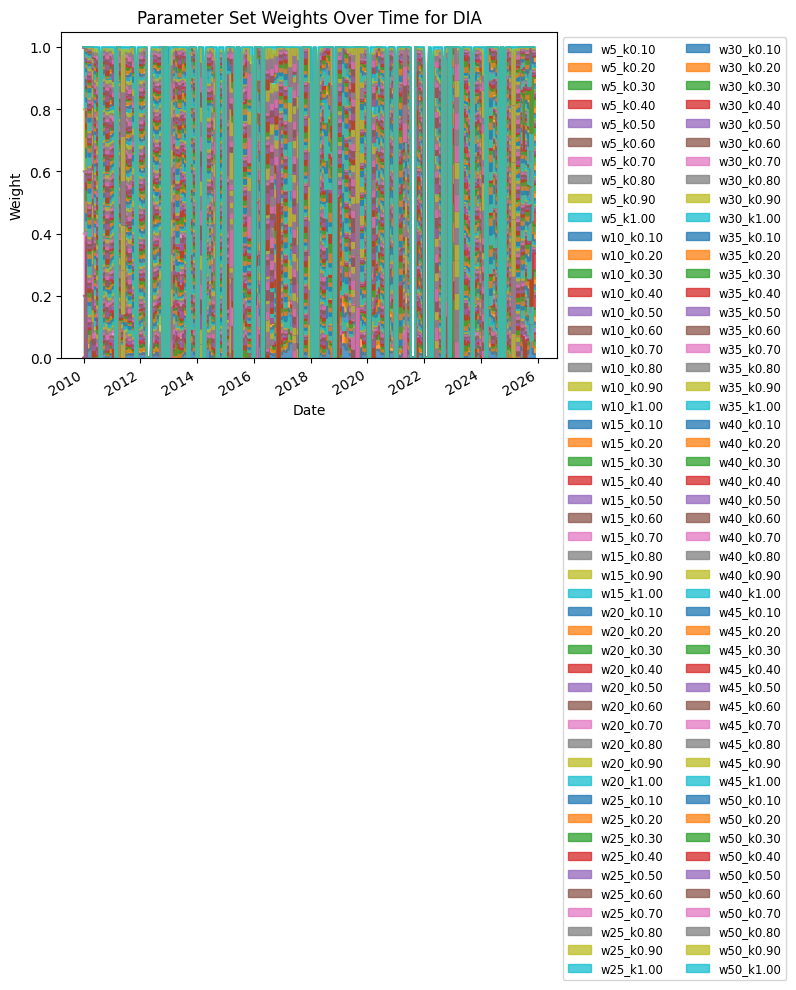

/tmp/ipython-input-3798583896.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

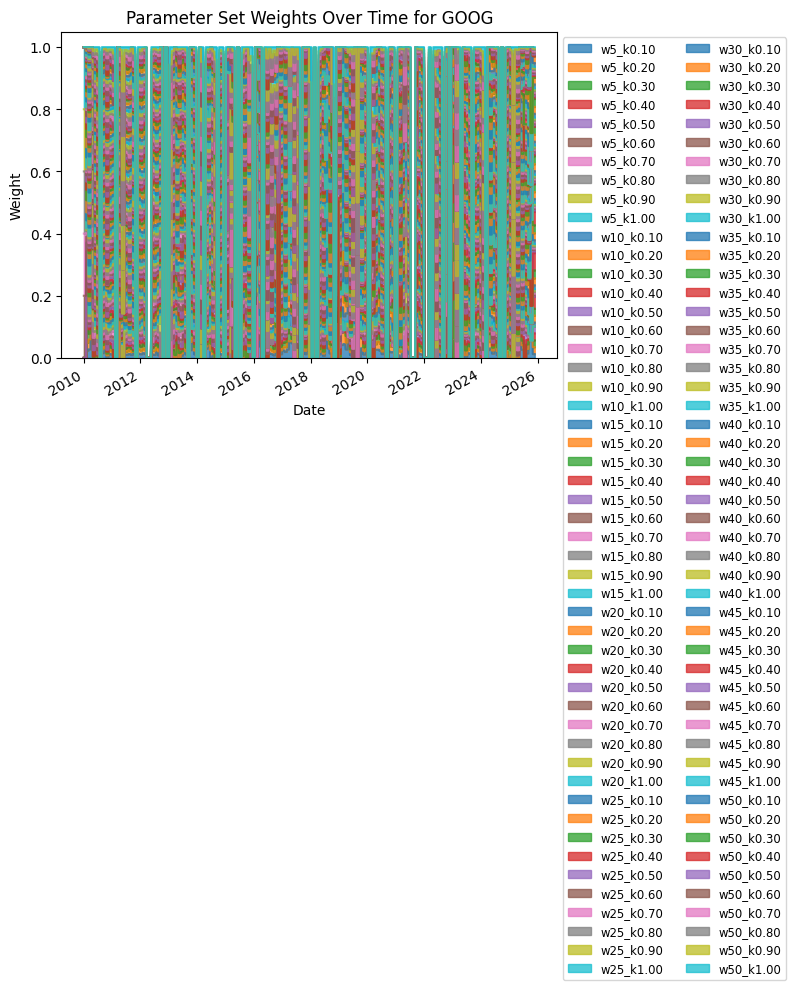

/tmp/ipython-input-3798583896.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

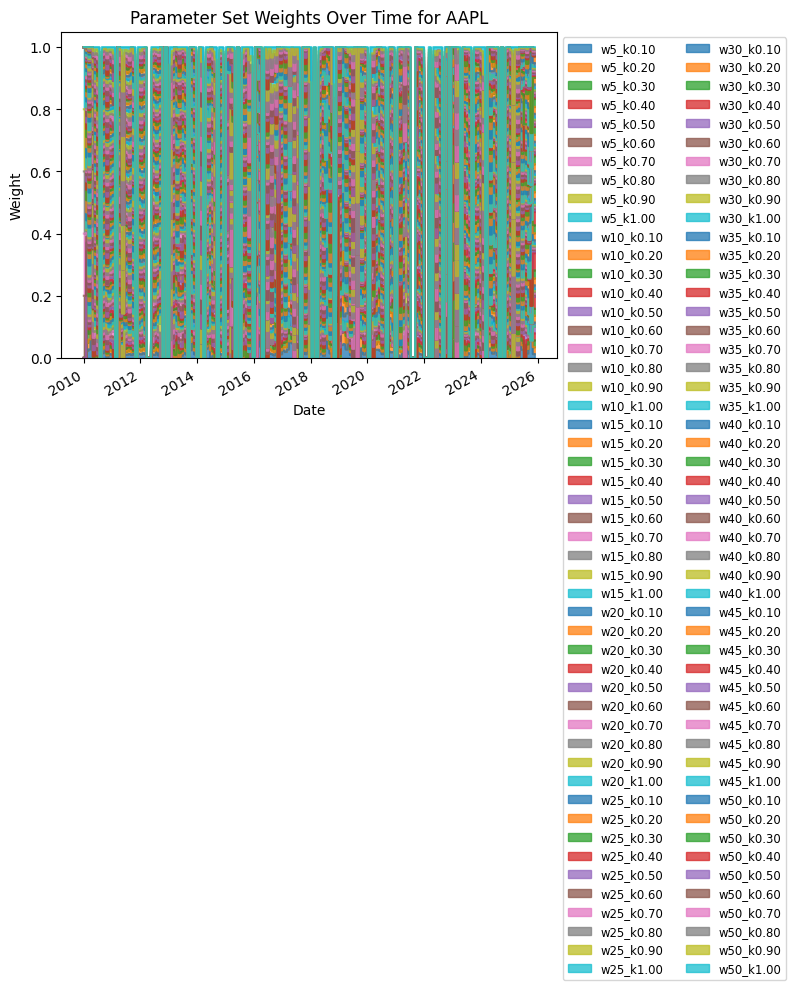

In [25]:
import matplotlib.pyplot as plt

tickers = close_prices.columns.tolist()
rebalance_period = 20

for ticker in tickers:
    # Assume all_strategy_returns calculated as before, indexed by date and columns = parameter strings

    # Collect weights at each rebalance period
    weights_over_time = pd.DataFrame(index=all_strategy_returns.index, columns=all_strategy_returns.columns)

    previous_weights = pd.Series(0, index=all_strategy_returns.columns)

    for start in range(0, len(all_strategy_returns), rebalance_period):
        end = min(start + rebalance_period, len(all_strategy_returns))
        window_returns = all_strategy_returns.iloc[start:end]

        performance = (1 + window_returns).prod() - 1
        positive_perf = performance.clip(lower=0)
        total_perf = positive_perf.sum()

        if total_perf == 0:
            weights = positive_perf * 0
        else:
            weights = positive_perf / total_perf

        weights_over_time.iloc[start:end] = weights.values  # fill weights for the entire period

        previous_weights = weights

    weights_over_time.fillna(0, inplace=True)

    # Plot stacked area of weights to show parameter set allocation over time
    plt.figure(figsize=(12, 6))
    weights_over_time.plot.area(stacked=True, alpha=0.75)
    plt.title(f'Parameter Set Weights Over Time for {ticker}')
    plt.ylabel('Weight')
    plt.xlabel('Date')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()
